# Helpers

In [22]:
import os
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import spearmanr

In [23]:
def create_item_id(df):
    cols_a = [col for col in df.columns if "a_" in col]
    cols_b = [col.replace('a_','b_') for col in cols_a]
    df['item_a'] = df.apply(lambda row: '-'.join([row[colname] for colname in cols_a]), axis=1)
    df['item_b'] = df.apply(lambda row: '-'.join([row[colname] for colname in cols_b]), axis=1)
    return df


def create_item_mapping(df_raw_scores: pd.DataFrame,
                        item_i_col='option_a',
                        item_j_col='option_b') -> dict:
    """Maps unique string items to integer indices 0 to N-1."""
    items = pd.concat([df_raw_scores[item_i_col], df_raw_scores[item_j_col]]).unique()
    return {item: idx for idx, item in enumerate(sorted(items))}

def fit_bradley_terry_statsmodels(df: pd.DataFrame, item_mapping: dict, 
                              item_i_col='option_a', item_j_col='option_b',
                              score_a_col='score_a', score_b_col='score_b') -> dict:
    """
    Fits the Bradley-Terry model with Positional Bias and returns a structured dictionary.
    """
    n_samples = len(df)
    n_items = len(item_mapping)
    
    # 1. Target Variable Y (Log-Odds)
    Y = (df[score_a_col] - df[score_b_col]).values
    
    # 2. Design Matrix X
    X_base = np.zeros((n_samples, n_items))
    i_indices = df[item_i_col].map(item_mapping).values
    j_indices = df[item_j_col].map(item_mapping).values
    
    row_indices = np.arange(n_samples)
    X_base[row_indices, i_indices] = 1
    X_base[row_indices, j_indices] = -1
    
    # Drop the last item column to avoid perfect multicollinearity
    X_base = X_base[:, :-1] 
    
    # Add the Intercept for gamma (Positional Bias)
    X = sm.add_constant(X_base) 
    
    # 3. Fit the OLS Model
    model = sm.OLS(Y, X)
    results = model.fit()
    
    # 4. Extract Bias and P-Value
    # 'const' is always at index 0 in statsmodels when using add_constant
    gamma_bias = results.params[0]
    gamma_pvalue = results.pvalues[0]
    
    # 5. Extract and format Item Scores
    # The coefficients for the items start at index 1. 
    # We append a 0.0 for the reference item we dropped earlier.
    raw_item_scores = np.append(results.params[1:], 0.0)
    
    # Mean-center the scores so they are centered around 0 (standard for BT models)
    centered_scores = raw_item_scores - np.mean(raw_item_scores)
    
    # Reverse the mapping to get {index: 'ItemName'}
    idx_to_item = {idx: item for item, idx in item_mapping.items()}
    
    # Create a dictionary of {ItemName: Score}
    item_scores_dict = {idx_to_item[i]: score for i, score in enumerate(centered_scores)}
    
    # 6. Compile the final dictionary
    output_dict = {
        "item_scores": item_scores_dict,
        "positional_bias_gamma": gamma_bias,
        "gamma_pvalue": gamma_pvalue,
        "model_r_squared": results.rsquared, # Good to keep for diagnostics!
        "f_stat_pvalue": results.f_pvalue    # Tests if the whole model is significant
    }
    
    return output_dict

def fit_feature_based_bradley_terry(df: pd.DataFrame, 
                                    a_prefix='a_', b_prefix='b_',
                                    score_a_col='score_a', score_b_col='score_b') -> dict:
    """
    Fits a Feature-Based Bradley-Terry model with Positional Bias.
    Automatically detects categorical features and handles dummy encoding.
    """
    n_samples = len(df)
    
    # 1. Target Variable Y (Log-Odds)
    Y = (df[score_a_col] - df[score_b_col]).values
    
    # 2. Automatically detect feature columns
    cols_a = [col for col in df.columns if col.startswith(a_prefix)]
    cols_b = [col.replace(a_prefix, b_prefix) for col in cols_a]
    
    # Extract the base feature names (e.g., 'a_brand' -> 'brand')
    base_features = [col[len(a_prefix):] for col in cols_a]
    
    # 3. Standardize and align the feature sets
    # We rename the columns so both A and B share the exact same column names
    df_a = df[cols_a].rename(columns=dict(zip(cols_a, base_features)))
    df_b = df[cols_b].rename(columns=dict(zip(cols_b, base_features)))
    
    # Combine A and B vertically. This is crucial! 
    # It ensures that pd.get_dummies() sees all possible categories across the entire 
    # dataset and drops the EXACT SAME reference level for both Option A and Option B.
    df_combined = pd.concat([df_a, df_b], axis=0)
    
    # Create dummy variables (dropping the first level to avoid multicollinearity)
    # We cast to float to ensure statsmodels handles it cleanly
    df_combined_dummies = pd.get_dummies(df_combined, drop_first=True, dtype=float)
    
    # Split them back apart into A and B matrices
    dummies_a = df_combined_dummies.iloc[:n_samples]
    dummies_b = df_combined_dummies.iloc[n_samples:]
    
    # 4. Create the Design Matrix X (Features A - Features B)
    X_base = dummies_a.values - dummies_b.values
    feature_names = dummies_a.columns.tolist()
    
    # Add the Intercept for gamma (Positional Bias)
    X = sm.add_constant(X_base)
    
    # 5. Fit the OLS Model
    model = sm.OLS(Y, X)
    results = model.fit()
    
    # 6. Extract Bias
    gamma_bias = results.params[0]
    gamma_pvalue = results.pvalues[0]
    
    # 7. Extract Feature Utilities (Weights)
    # Coefficients start at index 1 (index 0 is the intercept)
    feature_weights = results.params[1:]
    feature_pvalues = results.pvalues[1:]
    
    # Create dictionaries mapping the specific feature category to its learned utility
    feature_scores_dict = {feat: weight for feat, weight in zip(feature_names, feature_weights)}
    feature_pvalues_dict = {feat: pval for feat, pval in zip(feature_names, feature_pvalues)}
    
    # 8. Compile the final dictionary
    output_dict = {
        "feature_scores": feature_scores_dict,
        "feature_pvalues": feature_pvalues_dict,
        "positional_bias_gamma": gamma_bias,
        "gamma_pvalue": gamma_pvalue,
        "model_r_squared": results.rsquared, 
        "f_stat_pvalue": results.f_pvalue    
    }
    
    return output_dict

def fit_item_bradley_terry(df, a_prefix="a_", b_prefix="b_"):
    """
    Fits the feature-based Bradley-Terry model (one additive weight per feature
    level: brand, screen, ram, ...) and then computes each laptop's utility in
    post-processing as the sum of its own feature weights. This assumes the
    features contribute additively (no brand x screen interaction, etc.) - a
    more constrained model than fitting a separate coefficient per laptop.
    """
    feature_scores = fit_feature_based_bradley_terry(df, a_prefix=a_prefix, b_prefix=b_prefix)["feature_scores"]

    cols_a = [col for col in df.columns if col.startswith(a_prefix)]
    cols_b = [col.replace(a_prefix, b_prefix) for col in cols_a]
    base_features = [col[len(a_prefix):] for col in cols_a]

    # Every unique laptop is a unique combination of feature values seen as
    # either option A or option B anywhere in the data
    df_a = df[cols_a].rename(columns=dict(zip(cols_a, base_features)))
    df_b = df[cols_b].rename(columns=dict(zip(cols_b, base_features)))
    unique_laptops = pd.concat([df_a, df_b], axis=0).drop_duplicates()

    item_scores = {}
    for _, row in unique_laptops.iterrows():
        item_label = "-".join(str(row[feat]) for feat in base_features)
        item_scores[item_label] = sum(
            feature_scores.get(f"{feat}_{row[feat]}", 0.0) for feat in base_features
        )

    return item_scores

def compute_adherence_rank_correlations(scores_by_run, run_order, screen_marker_value="14-inch"):
    """
    For each consecutive pair of experiments in run_order, computes the Spearman
    rank correlation of laptop utility separately within the laptops that adhere
    to `screen_marker_value` and within the ones that don't - i.e. whether each
    group's own internal relative ordering (driven by brand/ram) survives the
    shift, independent of the constraint's main effect. Automatically covers
    every consecutive shift, so adding a third (or later) experiment to run_order
    adds its shift's correlations without any other changes.

    Returns a list of per-shift result dicts; also prints a readable summary.
    """
    results = []
    for run_a, run_b in zip(run_order, run_order[1:]):
        common_items = sorted(set(scores_by_run[run_a]) & set(scores_by_run[run_b]))
        adhering = [item for item in common_items if screen_marker_value in item]
        violating = [item for item in common_items if screen_marker_value not in item]

        def group_corr(items):
            if len(items) < 2:
                return float("nan"), len(items)
            a = [scores_by_run[run_a][item] for item in items]
            b = [scores_by_run[run_b][item] for item in items]
            rho, _ = spearmanr(a, b)
            return rho, len(items)

        adhere_rho, n_adhere = group_corr(adhering)
        violate_rho, n_violate = group_corr(violating)

        results.append({
            "shift": f"{run_a} -> {run_b}",
            "adhere_rho": adhere_rho, "n_adhere": n_adhere,
            "violate_rho": violate_rho, "n_violate": n_violate,
        })

        print(f"Shift {run_a} -> {run_b}:")
        print(f"  Adhering  ({screen_marker_value}, n={n_adhere}): rho = {adhere_rho:.3f}")
        print(f"  Violating (not {screen_marker_value}, n={n_violate}): rho = {violate_rho:.3f}")

    return results


## Plotting

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

def plot_preference_shift(df: pd.DataFrame, 
                          feature_col: str = 'Brand',
                          w_base_col: str = 'Weight_32_Base', 
                          p_base_col: str = 'Pval_32_Base',
                          w_constrained_col: str = 'Weight_32_14', 
                          p_constrained_col: str = 'Pval_32_14'):
    """
    Plots the shift in LLM latent utility weights between an unconstrained 
    and constrained condition. Automatically fades bars that are not 
    statistically significant (p > 0.05).
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Setup X-axis positions
    x = np.arange(len(df))
    width = 0.35  
    
    # Define primary colors
    color_base = '#1f77b4'      # Deep Blue
    color_constrained = '#ff7f0e' # Bright Orange
    
    # Significance threshold
    alpha_sig = 1.0  # Solid color if significant
    alpha_insig = 0.25 # Faded color if mostly noise (p > 0.05)

    # Plot each bar individually so we can apply specific opacity based on p-value
    for i in range(len(df)):
        # Base Condition (32-)
        alpha1 = alpha_sig if df.loc[i, p_base_col] <= 0.05 else alpha_insig
        ax.bar(x[i] - width/2, df.loc[i, w_base_col], width, 
               color=color_base, alpha=alpha1, edgecolor='black', linewidth=0.5)
        
        # Constrained Condition (32-14)
        alpha2 = alpha_sig if df.loc[i, p_constrained_col] <= 0.05 else alpha_insig
        ax.bar(x[i] + width/2, df.loc[i, w_constrained_col], width, 
               color=color_constrained, alpha=alpha2, edgecolor='black', linewidth=0.5)

    # Add a horizontal zero-line for the baseline reference
    ax.axhline(0, color='black', linewidth=1.2, linestyle='-')

    # Formatting and Labels
    ax.set_ylabel('Latent Utility (Log-Odds Weight)', fontsize=12, fontweight='bold')
    ax.set_title('Preference Flattening: Impact of "14-inch" Constraint on Brand Bias', 
                 fontsize=14, pad=15)
    
    ax.set_xticks(x)
    ax.set_xticklabels(df[feature_col], rotation=45, ha='right', fontsize=11)
    
    # Custom Legend
    legend_elements = [
        Patch(facecolor=color_base, label='Unconstrained (32GB RAM)', alpha=alpha_sig),
        Patch(facecolor=color_constrained, label='Constrained (+14-inch Screen)', alpha=alpha_sig),
        Patch(facecolor='gray', label='Not Significant (p > 0.05)', alpha=alpha_insig)
    ]
    ax.legend(handles=legend_elements, loc='upper right', framealpha=0.9)

    plt.tight_layout()
    plt.show()

def plot_laptop_ranking_shift(scores_by_run, run_order, constraints_by_run,
                               constraint_markers=None, figsize=None, label_fontsize=7):
    """
    Bump chart of per-laptop preference RANK across experiment conditions.
    Each laptop (a full brand-screen-ram item) is one line; x = run key, y = rank
    (1 = most preferred, at the top).

    Color/linestyle are computed PER SEGMENT (run_a -> run_b), not once per
    laptop, since which constraints are "previous" vs "new" changes from one
    shift to the next: `prev` is the full set of constraint tokens already
    active at run_a (vacuously satisfied by everyone if run_a is
    unconstrained), and `new` is whatever token(s) run_b adds on top of that.
    A laptop is classified by whether it matches ALL of `prev` and ALL of
    `new`:
      - matches prev and new     -> solid, bold deep pink  (adheres to all)
      - matches prev, not new    -> solid, light pink       (adheres to previous only)
      - matches new, not prev    -> dashed, deep pink       (adheres to new only)
      - matches neither          -> solid, muted gray

    constraints_by_run: {run_key: raw constraints string} as returned by
        load_scores_by_run, e.g. {"32-": "", "32-14": "14", "32-14_8": "14_8"}.
    constraint_markers: {constraint token: substring to look for in the item
        label} - defaults to {"14": "14-inch", "8": "8GB"}. A laptop
        "adheres" to a token if that substring is in its item label.

    Every laptop is labeled at its rank row on both sides, colored to match
    its first/last segment respectively. Works for any number of experiments
    in run_order (>= 2), and run_order doesn't need to start from an
    unconstrained baseline run.

    scores_by_run: {run_key: {item_name: score}}
    """
    if constraint_markers is None:
        constraint_markers = {"14": "14-inch", "8": "8GB"}

    # Only laptops present in every run can be drawn as a connected line
    common_items = set(scores_by_run[run_order[0]])
    for rk in run_order[1:]:
        common_items &= set(scores_by_run[rk])
    items = sorted(common_items)
    n = len(items)

    # Rank within each run: 1 = highest utility (most preferred)
    ranks_by_run = {}
    for rk in run_order:
        s = pd.Series({item: scores_by_run[rk][item] for item in items})
        ranks_by_run[rk] = s.rank(ascending=False, method="first").astype(int)

    x = np.arange(len(run_order))

    color_all = "#d6336c"        # adheres to all (previous + new)
    color_prev_only = "#ff8fab"  # adheres to previous only (lighter pink)
    color_new_only = "#9d174d"   # adheres to new only (deep pink, dashed)
    color_none = "#adb5bd"       # adheres to neither (muted gray)

    def tokens_of(run_key):
        return set(t for t in constraints_by_run[run_key].split("_") if t)

    def matches_all(item, tokens):
        return all(constraint_markers[t] in item for t in tokens)

    def style_for_segment(item, run_a, run_b):
        prev_tokens = tokens_of(run_a)
        new_tokens = tokens_of(run_b) - prev_tokens
        adheres_prev = matches_all(item, prev_tokens)
        adheres_new = matches_all(item, new_tokens)
        if adheres_prev and adheres_new:
            return dict(color=color_all, linestyle="-", linewidth=1.8, alpha=0.95, zorder=4)
        if adheres_prev:
            return dict(color=color_prev_only, linestyle="-", linewidth=1.4, alpha=0.9, zorder=3)
        if adheres_new:
            return dict(color=color_new_only, linestyle="--", linewidth=1.4, alpha=0.9, zorder=3)
        return dict(color=color_none, linestyle="-", linewidth=1.0, alpha=0.5, zorder=2)

    if figsize is None:
        figsize = (4 + 3 * len(run_order), max(6, n * 0.32))

    fig, ax = plt.subplots(figsize=figsize)

    n_segments = len(run_order) - 1
    for item in items:
        y = [ranks_by_run[rk][item] for rk in run_order]
        for seg_idx in range(n_segments):
            style = style_for_segment(item, run_order[seg_idx], run_order[seg_idx + 1])
            ax.plot(x[seg_idx:seg_idx + 2], y[seg_idx:seg_idx + 2], marker="o", markersize=4,
                    markeredgecolor="white", markeredgewidth=0.4, **style)

        # Row labels aligned to this laptop's rank at each end, colored to match
        # the segment touching that end - no overlap since rank is a unique
        # integer y-position per line
        left_color = style_for_segment(item, run_order[0], run_order[1])["color"]
        right_color = style_for_segment(item, run_order[-2], run_order[-1])["color"]
        ax.text(x[0] - 0.05, y[0], item, ha="right", va="center",
                fontsize=label_fontsize, color=left_color)
        ax.text(x[-1] + 0.05, y[-1], item, ha="left", va="center",
                fontsize=label_fontsize, color=right_color)

    ax.set_ylim(n + 1, 0)  # rank 1 at the top
    ax.set_yticks([])
    ax.set_xticks(x)
    ax.set_xticklabels(run_order, fontsize=11, fontweight="bold")
    ax.set_xlim(x[0] - 1.1, x[-1] + 1.1)  # room for the row labels on both sides
    ax.set_title("Laptop Preference Ranking Across Experiments", fontsize=14, fontweight="bold", pad=44)

    for spine in ax.spines.values():
        spine.set_visible(False)

    legend_handles = [
        Line2D([0], [0], color=color_all, linewidth=2, linestyle="-",
               label="Adheres to all constraints"),
        Line2D([0], [0], color=color_prev_only, linewidth=2, linestyle="-",
               label="Adheres to previous only"),
        Line2D([0], [0], color=color_new_only, linewidth=2, linestyle="--",
               label="Adheres to new only"),
        Line2D([0], [0], color=color_none, linewidth=2, linestyle="-",
               label="Adheres to neither"),
    ]
    ax.legend(handles=legend_handles, loc="lower center", bbox_to_anchor=(0.5, 1.005),
              ncol=4, frameon=False, title="Constraint adherence (per shift)", fontsize=9)

    plt.tight_layout()
    plt.show()
    return fig, ax

# Robustness New

In [25]:
def load_scores_by_run(basedir, filters, constraint_order, fit_fn=fit_item_bradley_terry):
    """
    Loads and fits one Bradley-Terry model per experiment run under `basedir`.

    filters: dict of config.json keys that must match exactly to select a
        family of runs, e.g. {"model_size": "7"} or
        {"model_family": "gemma", "model_size": "27"}.
    constraint_order: canonical list of `constraints` values defining the run
        order, e.g. ["", "14", "14_8"].

    Returns (scores_by_run, run_order, constraints_by_run). scores_by_run is
    keyed by f"{'-'.join(filters.values())}-{constraints}" (matching the
    original CANONICAL_RUN_ORDER naming, e.g. "7-14"); run_order is
    constraint_order filtered down to the runs actually found on disk, in
    canonical order - so the plot/correlations grow automatically as more
    experiments land. constraints_by_run maps each run_key back to its raw
    constraints string (e.g. "7-14_8" -> "14_8"), for callers (like
    plot_laptop_ranking_shift) that need to know which constraints are
    actually active in each run.
    """
    prefix = "-".join(str(v) for v in filters.values())
    scores_by_run = {}
    constraints_by_run = {}

    for filename in os.listdir(basedir):
        config_path = os.path.join(basedir, filename, "config.json")
        scores_path = os.path.join(basedir, filename, "scores.csv")
        if not os.path.isfile(config_path) or not os.path.isfile(scores_path):
            continue
        with open(config_path, "r") as f:
            config = json.load(f)

        if any(config.get(key, "") != value for key, value in filters.items()):
            continue

        constraints = config.get("constraints", "") or ""
        if constraints not in constraint_order:
            continue

        run_key = f"{prefix}-{constraints}"
        print(f"Loaded {filename} -> {run_key}")
        df = pd.read_csv(scores_path)
        scores_by_run[run_key] = fit_fn(df)
        constraints_by_run[run_key] = constraints

    run_order = [f"{prefix}-{c}" for c in constraint_order if f"{prefix}-{c}" in scores_by_run]
    missing = [f"{prefix}-{c}" for c in constraint_order if f"{prefix}-{c}" not in scores_by_run]
    if missing:
        print(f"Note: still missing {missing} (job may still be running) - rerun this cell once it lands.")

    return scores_by_run, run_order, constraints_by_run


def run_laptop_ranking_experiment(basedir, filters, constraint_order, fit_fn=fit_item_bradley_terry, **plot_kwargs):
    """
    End-to-end reuse point for the slopegraph: load+fit every run matching
    `filters` under `basedir`, draw the ranking bump chart, and print the
    adherence rank correlations for each consecutive shift in
    `constraint_order`. See load_scores_by_run for the argument details -
    swap `filters` for a different model size/family, or `constraint_order`
    for a different constraint sequence.

    Returns (scores_by_run, run_order, correlation_results).
    """
    scores_by_run, run_order, constraints_by_run = load_scores_by_run(basedir, filters, constraint_order, fit_fn=fit_fn)
    plot_laptop_ranking_shift(scores_by_run, run_order=run_order, constraints_by_run=constraints_by_run, **plot_kwargs)
    correlation_results = compute_adherence_rank_correlations(scores_by_run, run_order=run_order)
    return scores_by_run, run_order, correlation_results

Loaded 68339919 -> 32-14
Loaded 68373841 -> 32-
Loaded 68374115 -> 32-14_8


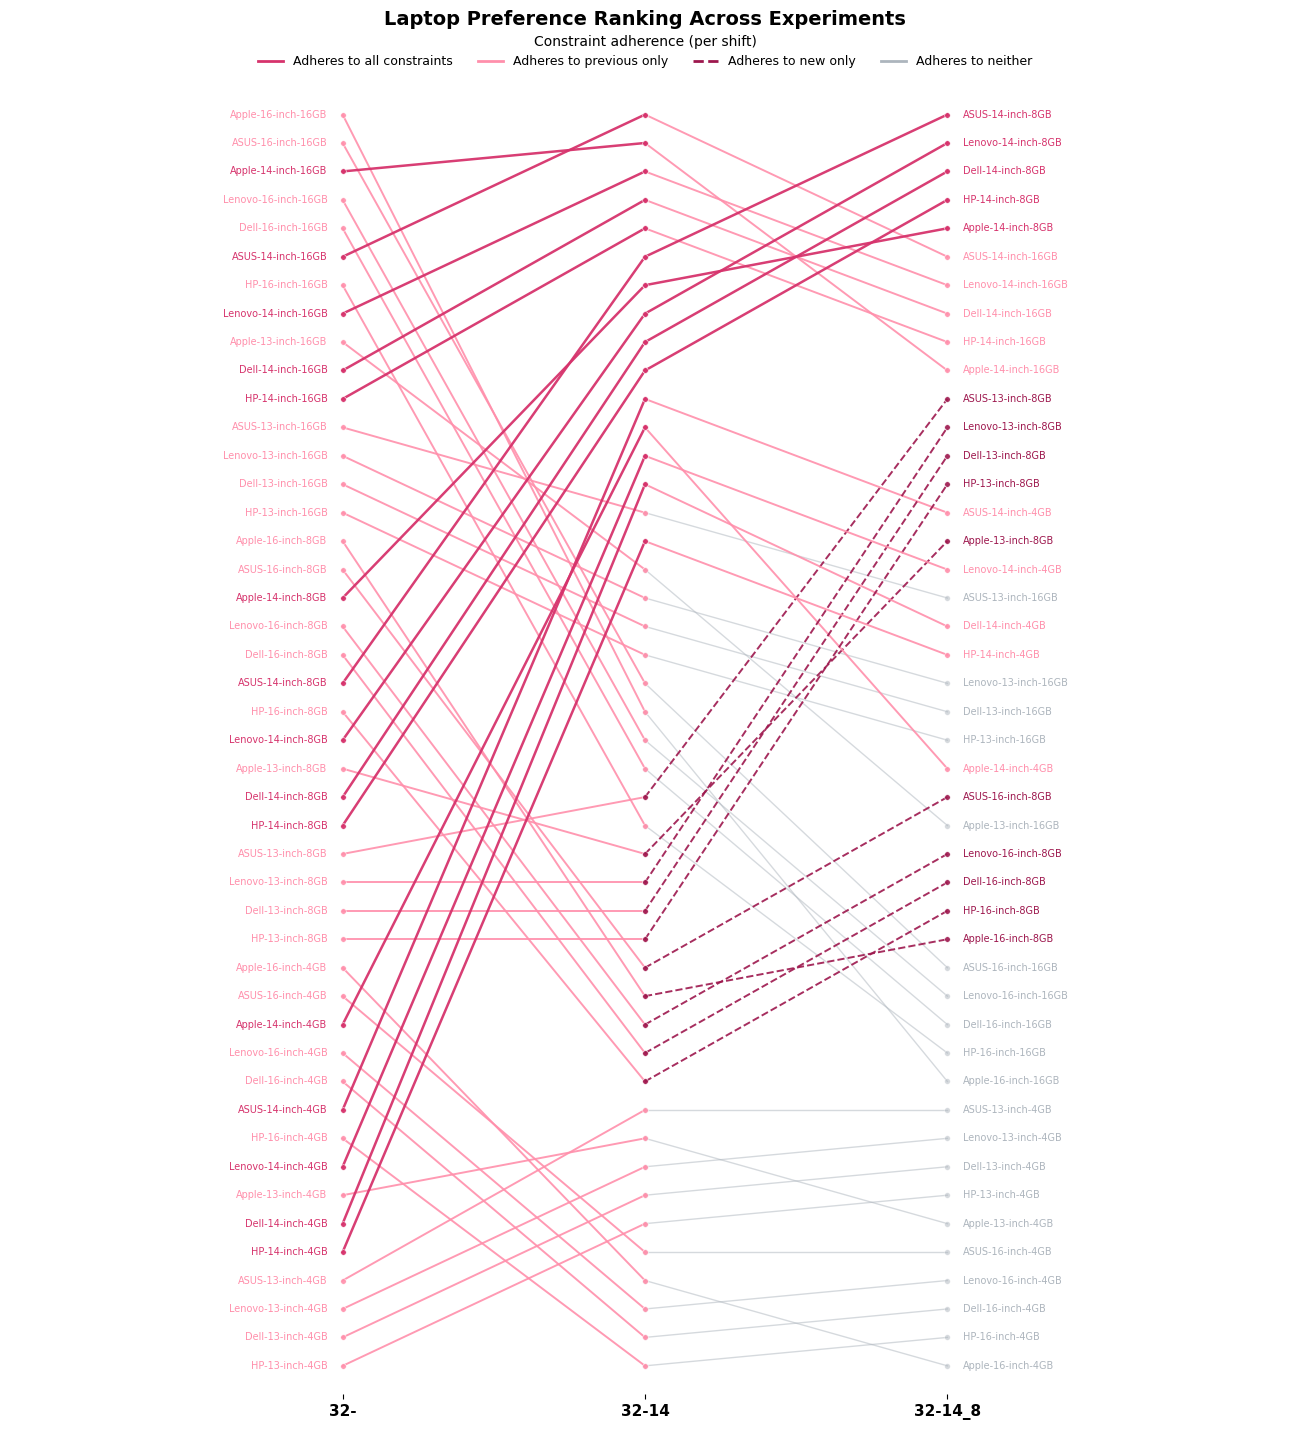

Shift 32- -> 32-14:
  Adhering  (14-inch, n=15): rho = 0.989
  Violating (not 14-inch, n=30): rho = 0.825
Shift 32-14 -> 32-14_8:
  Adhering  (14-inch, n=15): rho = 0.489
  Violating (not 14-inch, n=30): rho = 0.708


In [26]:
scores_by_run, run_order, correlation_results = run_laptop_ranking_experiment(
    basedir="data/laptops_robustness",
    filters={"model_size": "32"},
    constraint_order=["", "14", "14_8"],
)

Loaded 68337596 -> 7-14
Loaded 68373840 -> 7-
Loaded 68374113 -> 7-14_8


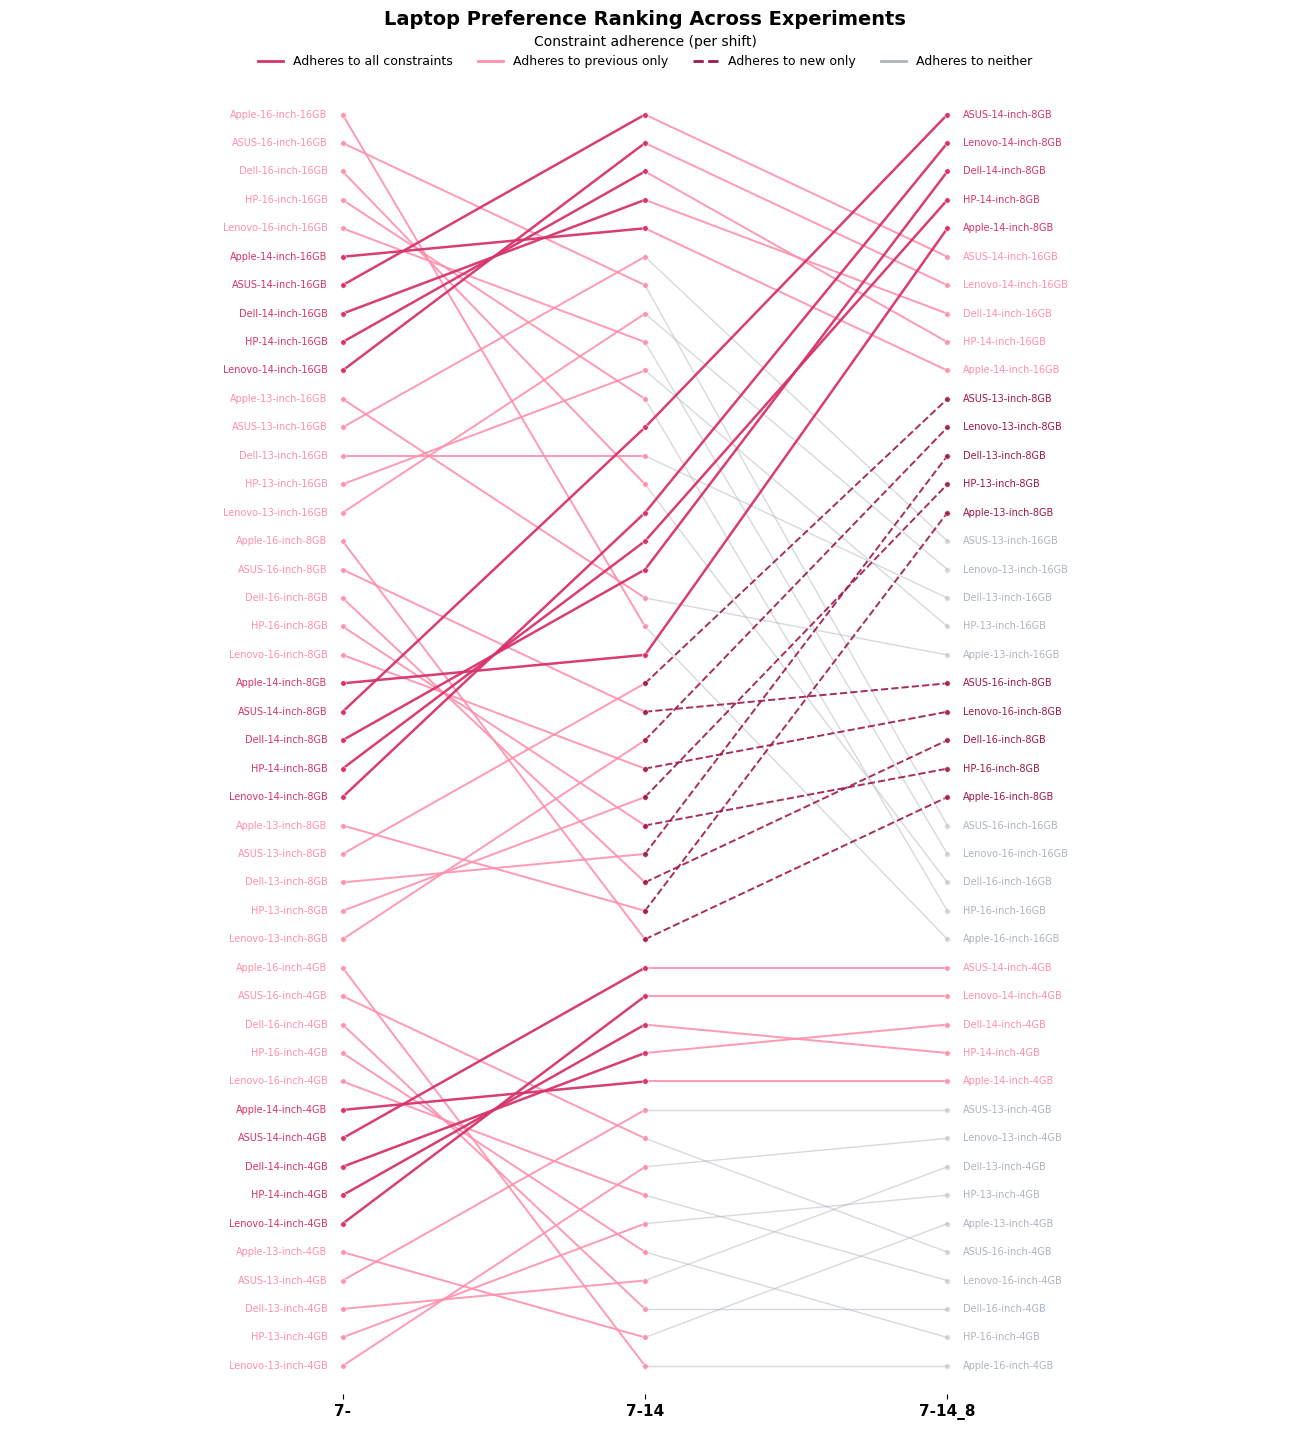

Shift 7- -> 7-14:
  Adhering  (14-inch, n=15): rho = 0.850
  Violating (not 14-inch, n=30): rho = 0.852
Shift 7-14 -> 7-14_8:
  Adhering  (14-inch, n=15): rho = 0.543
  Violating (not 14-inch, n=30): rho = 0.632


In [27]:
scores_by_run, run_order, correlation_results = run_laptop_ranking_experiment(
    basedir="data/laptops_robustness",
    filters={"model_size": "7"},
    constraint_order=["", "14", "14_8"],
)

Loaded 68339918 -> 0.5-14
Loaded 68374669 -> 0.5-14_8
Note: still missing ['0.5-'] (job may still be running) - rerun this cell once it lands.


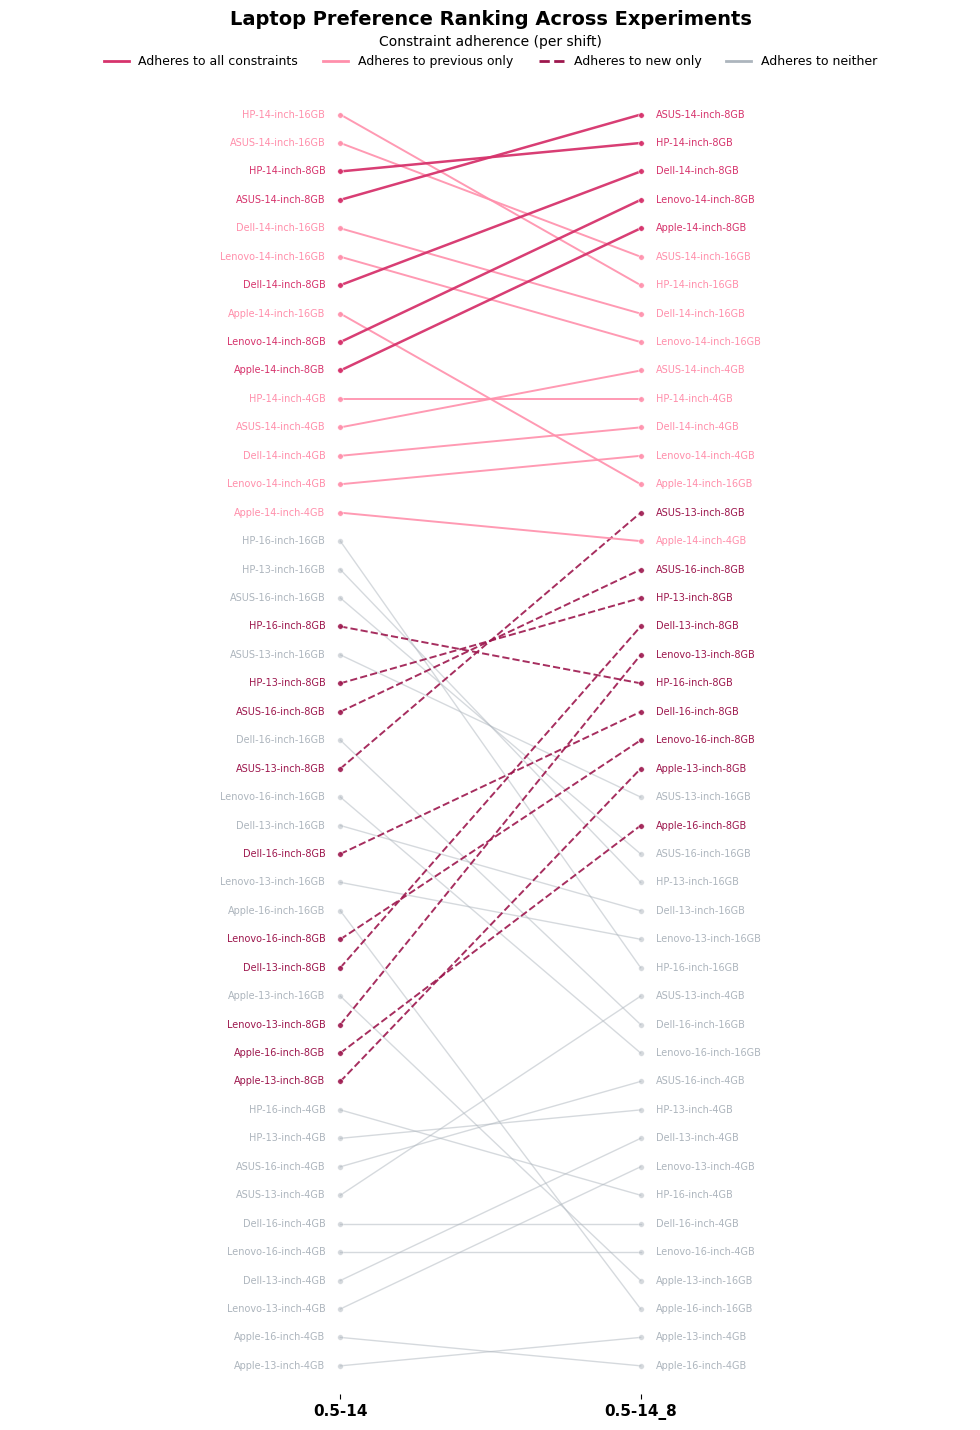

Shift 0.5-14 -> 0.5-14_8:
  Adhering  (14-inch, n=15): rho = 0.664
  Violating (not 14-inch, n=30): rho = 0.614


In [28]:
scores_by_run, run_order, correlation_results = run_laptop_ranking_experiment(
    basedir="data/laptops_robustness",
    filters={"model_size": "0.5"},
    constraint_order=["", "14", "14_8"],
)

# Misc

In [29]:
records = []
basedir = "data/laptops_robustness"
for filename in os.listdir(basedir):
    config_path = os.path.join(basedir, filename, "config.json")
    scores_path = os.path.join(basedir, filename, "scores.csv")
    if not os.path.isfile(config_path) or not os.path.isfile(scores_path):
        continue
    with open(config_path, "r") as f:
        config = json.load(f)
    records.append({
        'filename': filename,
        'model_family': config.get("model_family", ""),
        'model_size': config.get("model_size", ""), 
        'constraints': config.get("constraints", "") or "",
    })

df = pd.DataFrame(records)
df

,filename,model_family,model_size,constraints
0,68337596,qwen,7,14
1,68339918,qwen,0.5,14
2,68339919,qwen,32,14
3,68339920,qwen,72,14
4,68373840,qwen,7,
5,68373841,qwen,32,
6,68374112,qwen,7,8
7,68374113,qwen,7,14_8
8,68374114,qwen,32,8
9,68374115,qwen,32,14_8


In [30]:
sizes = df['model_size'].unique()
constraints = df['constraints'].unique()
do_we_have = np.zeros((len(sizes), len(constraints)), dtype=int)
for i, size in enumerate(sizes):
    for j, constraint in enumerate(constraints):
        do_we_have[i, j] = ((df['model_size'] == size) & (df['constraints'] == constraint)).sum()
        
do_we_have = pd.DataFrame(do_we_have, index=sizes, columns=constraints)
do_we_have

,14,,8,14_8
7,1,1,1,1
0.5,1,0,1,1
32,1,1,1,1
72,1,0,1,1


In [31]:
records = []
basedir = "data/laptops_robustness_gemma"
for filename in os.listdir(basedir):
    config_path = os.path.join(basedir, filename, "config.json")
    scores_path = os.path.join(basedir, filename, "scores.csv")
    if not os.path.isfile(config_path) or not os.path.isfile(scores_path):
        continue
    with open(config_path, "r") as f:
        config = json.load(f)
    records.append({
        'filename': filename,
        'model_family': config.get("model_family", ""),
        'model_size': config.get("model_size", ""), 
        'constraints': config.get("constraints", "") or "",
    })

df = pd.DataFrame(records)
df

,filename,model_family,model_size,constraints
0,68371857,gemma,1,
1,68371858,gemma,4,
2,68371859,gemma,12,
3,68371860,gemma,27,
4,68374673,gemma,1,14
5,68374674,gemma,1,8
6,68374675,gemma,1,14_8
7,68374676,gemma,4,14
8,68374677,gemma,4,8
9,68374678,gemma,4,14_8
